# Pipeline ETL: Logística e Manutenção Aeronáutica
**Alunos:** Otávio Castelani , Francisco Moreira
**Contexto:** Logística Aeronáutica 

Este projeto implementa um pipeline de dados para monitorar a disponibilidade da frota e custos de manutenção.

---

Nota de Compatibilidade: 

Este notebook foi desenvolvido utilizando Python 3.12. 

A primeira célula de código realiza a instalação das versões estritas das bibliotecas (numpy 1.26, pandas 2.2, matplotlib 3.8) para evitar conflitos conhecidos com atualizações recentes (Numpy 2.0).

Por favor, execute-a para garantir a visualização correta dos gráficos.

In [5]:
# --- SETUP DO AMBIENTE ---

import sys
!{sys.executable} -m pip install numpy==1.26.4 pandas==2.2.2 matplotlib==3.8.4

In [6]:
# Importação de Bibliotecas
import numpy
import pandas as pd
import unicodedata
import matplotlib.pyplot as plt

print(f"Versão Numpy: {numpy.__version__}")
print(f"Versão Pandas: {pd.__version__}")

# Configuração para gráficos ficarem bonitos
plt.style.use('ggplot')

# --- GERAÇÃO DA MASSA DE DADOS (SIMULAÇÃO) ---
# Criando o arquivo CSV 'sujo' para servir de fonte
dados_aeronauticos = {
    'matricula_aeronave': ['FAB-2850', 'FAB-2401', 'FAB-2850', 'FAB-5500', 'FAB-2401', 'FAB-9999', 'CIV-PT-X'],
    'componente': ['Motor PT6', 'Radar Meteorológico', 'Motor PT6', 'Trem de Pouso', 'Altímetro', None, 'Hélice'],
    'horas_voo_atuais': [1800.5, 200.0, 1800.5, 4200.0, -50.0, 10.0, 500.0],
    'tbo_horas_limite': [2000, 5000, 2000, 4000, 1000, 100, 2000],
    'custo_manutencao_previsto': [15000.00, 2500.00, 15000.00, 45000.00, 300.00, 0.0, 1200.00],
    'data_ultima_inspecao': ['2024-01-10', '2023-11-22', '2024-01-10', None, '2024-02-15', '2024-01-01', '2023-05-20']
}
pd.DataFrame(dados_aeronauticos).to_csv('manutencao_aeronaves.csv', index=False)
print("Ambiente preparado: Arquivo fonte criado.")

Versão Numpy: 1.26.4
Versão Pandas: 2.2.2
Ambiente preparado: Arquivo fonte criado.


# 🟢 ETAPA 1: EXTRACT (Extração)
Carregamento dos dados brutos do sistema legado (arquivo CSV).

In [7]:
try:
    df = pd.read_csv('manutencao_aeronaves.csv')
    print(f"Sucesso! {len(df)} registros carregados.")
    display(df.head()) # Visualiza as primeiras linhas (com sujeira)
except FileNotFoundError:
    print("Erro fatal: Arquivo não encontrado.")

Sucesso! 7 registros carregados.


,matricula_aeronave,componente,horas_voo_atuais,tbo_horas_limite,custo_manutencao_previsto,data_ultima_inspecao
0,FAB-2850,Motor PT6,1800.5,2000,15000.0,2024-01-10
1,FAB-2401,Radar Meteorológico,200.0,5000,2500.0,2023-11-22
2,FAB-2850,Motor PT6,1800.5,2000,15000.0,2024-01-10
3,FAB-5500,Trem de Pouso,4200.0,4000,45000.0,NaN
4,FAB-2401,Altímetro,-50.0,1000,300.0,2024-02-15


# 🟡 ETAPA 2: TRANSFORM (Transformação)
Nesta etapa realizamos a limpeza, padronização e aplicação de regras de negócio.

1. **Limpeza:** Remoção de duplicatas e nulos.
2. **Padronização:** Remoção de acentos e conversão para UPPERCASE.
3. **Enriquecimento:** Cálculo de horas restantes e definição de status (Vencido/Ok).

In [8]:
# --- 1. LIMPEZA ESTRUTURAL ---
df_clean = df.drop_duplicates() 
df_clean = df_clean.dropna(subset=['componente'])
df_clean = df_clean[df_clean['horas_voo_atuais'] >= 0]

# --- 2. PADRONIZAÇÃO DE TEXTO ---
def limpar_texto(texto):
    if isinstance(texto, str):
        nfkd = unicodedata.normalize('NFKD', texto)
        texto_limpo = "".join([c for c in nfkd if not unicodedata.combining(c)])
        return texto_limpo.upper()
    return texto

cols_texto = ['matricula_aeronave', 'componente']
for col in cols_texto:
    df_clean[col] = df_clean[col].apply(limpar_texto)

# --- 3. REGRAS DE NEGÓCIO (LÓGICA FAB) ---
df_clean['horas_restantes'] = df_clean['tbo_horas_limite'] - df_clean['horas_voo_atuais']

def definir_status(saldo):
    if saldo < 0: return "VENCIDO"    # Crítico
    elif saldo < 50: return "ALERTA"  # Atenção
    else: return "OPERACIONAL"        # OK

df_clean['status'] = df_clean['horas_restantes'].apply(definir_status)

print("Dados transformados com sucesso.")
display(df_clean)

Dados transformados com sucesso.


,matricula_aeronave,componente,horas_voo_atuais,tbo_horas_limite,custo_manutencao_previsto,data_ultima_inspecao,horas_restantes,status
0,FAB-2850,MOTOR PT6,1800.5,2000,15000.0,2024-01-10,199.5,OPERACIONAL
1,FAB-2401,RADAR METEOROLOGICO,200.0,5000,2500.0,2023-11-22,4800.0,OPERACIONAL
3,FAB-5500,TREM DE POUSO,4200.0,4000,45000.0,NaN,-200.0,VENCIDO
6,CIV-PT-X,HELICE,500.0,2000,1200.0,2023-05-20,1500.0,OPERACIONAL


# 🔴 ETAPA 3: LOAD (Carga e Visualização)
Exportação dos dados tratados e geração de dashboards para tomada de decisão.

Arquivo 'relatorio_final_frota.csv' salvo.


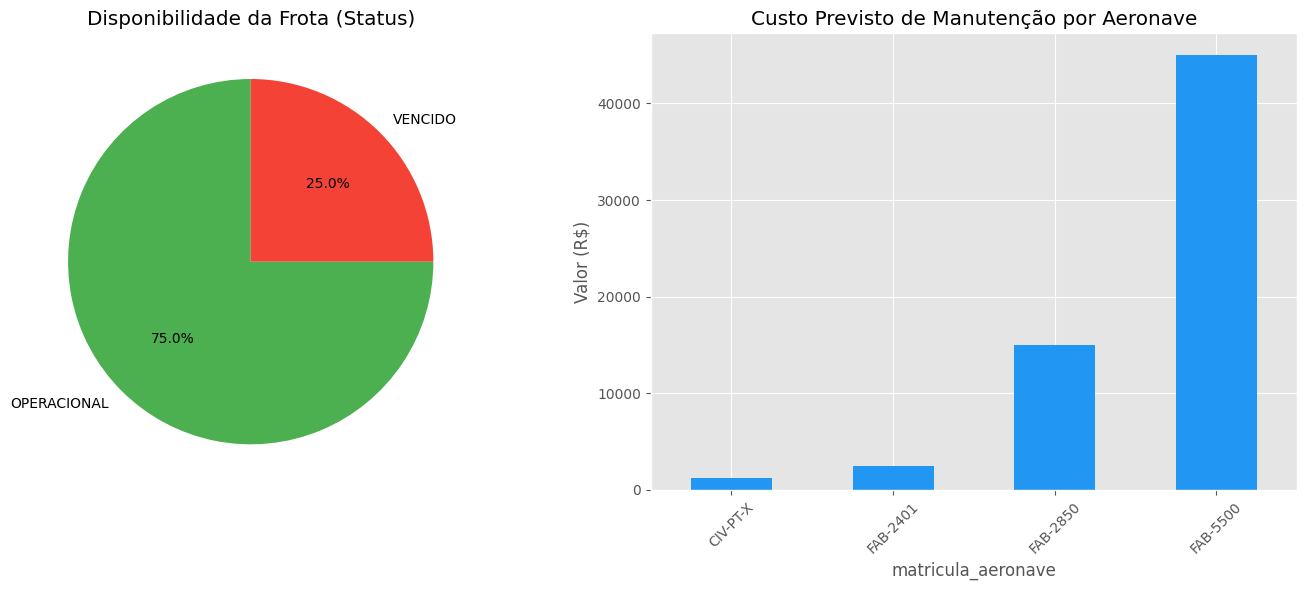

In [9]:
# A) Salvando Arquivos Finais
df_clean.to_csv('relatorio_final_frota.csv', index=False)
print("Arquivo 'relatorio_final_frota.csv' salvo.")

# B) Agregação para Gráficos
# Contagem de status
status_count = df_clean['status'].value_counts()
# Custo por aeronave
custo_aviao = df_clean.groupby('matricula_aeronave')['custo_manutencao_previsto'].sum()

# C) Visualização Gráfica
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Pizza (Disponibilidade da Frota)
cores = {'OPERACIONAL': '#4CAF50', 'ALERTA': '#FFC107', 'VENCIDO': '#F44336'}
cores_map = [cores.get(x, '#999999') for x in status_count.index]

status_count.plot(kind='pie', ax=ax1, autopct='%1.1f%%', colors=cores_map, startangle=90)
ax1.set_ylabel('')
ax1.set_title('Disponibilidade da Frota (Status)')

# Gráfico 2: Barras (Orçamento Previsto)
custo_aviao.plot(kind='bar', ax=ax2, color='#2196F3')
ax2.set_title('Custo Previsto de Manutenção por Aeronave')
ax2.set_ylabel('Valor (R$)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
# 🏁 Conclusão e Resultados Técnicos

Neste laboratório, foi desenvolvido um pipeline **ETL (Extract, Transform, Load)** completo, demonstrando a capacidade de converter dados brutos e não estruturados em inteligência de negócios para a manutenção aeronáutica.

### 📋 Resumo das Etapas Realizadas:

1.  **Extract (Extração):**
    * Simulação de ingestão de dados de um sistema legado (CSV).
    * Identificação de inconsistências comuns em ambientes reais (campos nulos, duplicatas e erros lógicos).

2.  **Transform (Transformação):**
    * **Sanitização:** Implementação de algoritmos robustos (`unicodedata`) para normalização de texto (remoção de acentos e padronização para *UPPERCASE*).
    * **Qualidade de Dados:** Filtragem lógica para remover registros fisicamente impossíveis (ex: horas de voo negativas).
    * **Regras de Negócio:** Criação da métrica calculada `status_operacional` baseada no TBO (*Time Between Overhaul*).

3.  **Load (Carga e Visualização):**
    * Persistência dos dados tratados em arquivos prontos para consumo (`.csv`).
    * Geração de dashboards visuais (Matplotlib) para apoio à tomada de decisão gerencial.

### 🚀 Melhorias Futuras
Para evoluir este projeto em um ambiente de produção real, sugere-se:
* Substituir o CSV por conexão direta via **SQLAlchemy** ou **API Rest**.
* Orquestrar a execução automática do script utilizando **Apache Airflow** ou **Cron Jobs**.
* Implementar testes unitários (`pytest`) para validar a integridade dos dados antes da carga final.